# 04 — SHAP Explainability Analysis

**Purpose**: compute and inspect global and local SHAP explanations for the
selected Random Forest model. This is the **technical/research half only** —
raw SHAP values, for the researcher to inspect.

**Explicitly out of scope here**: the Human-Centered Explanation Generator
(translating these values into supportive plain language for students). Per
`.claude/skills/explainable-ai/SKILL.md` that is a deliberately separate
step, and nothing in this notebook should be shown to an end user — every
plot and number below is exactly the kind of raw ML output the framework
exists to keep away from students.

**No training happens here.** This notebook loads the artifacts produced by
`03_ModelTraining.ipynb` and never refits a model — refitting could silently
produce a different model than the one documented in
`docs/governance/model_card.md`.

In [1]:
import json
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.model_selection import train_test_split

ARTIFACTS_DIR = Path("../artifacts")
MODEL_PATH = ARTIFACTS_DIR / "stress_model_v1.pkl"
SCHEMA_PATH = ARTIFACTS_DIR / "feature_schema.json"
MANIFEST_PATH = ARTIFACTS_DIR / "artifact_manifest.json"
DATA_PATH = "../datasets/raw/student_stress_factors.csv"

# Must match 03_ModelTraining.ipynb exactly to reproduce the same held-out set.
RANDOM_STATE = 42
TEST_SIZE = 0.2

print(f"shap {shap.__version__}")

shap 0.52.0


## Load artifacts (fail loudly if missing)

`stress_model_v1.pkl` is gitignored, so it only exists if
`03_ModelTraining.ipynb` has been run in this working copy. If it is absent
this cell raises rather than retraining — a freshly trained model could
differ subtly from the one whose metrics are already published in the model
card, which would silently invalidate the explanations below.

In [2]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model artifact not found at {MODEL_PATH.resolve()}.\n"
        "This file is gitignored and is only created by running "
        "03_ModelTraining.ipynb locally.\n"
        "NOT retraining automatically: a re-trained model could differ from the "
        "one documented in docs/governance/model_card.md, which would make these "
        "explanations describe a different model than the one reported.\n"
        "Fix: run 03_ModelTraining.ipynb first, then re-run this notebook."
    )

model = joblib.load(MODEL_PATH)
with open(SCHEMA_PATH, encoding="utf-8") as f:
    feature_schema = json.load(f)
with open(MANIFEST_PATH, encoding="utf-8") as f:
    manifest = json.load(f)

FEATURE_ORDER = [f["name"] for f in sorted(feature_schema["features"], key=lambda d: d["position"])]
CLASS_LABELS = feature_schema["target"]["classes"]
CLASS_MEANING = feature_schema["target"]["class_meaning"]
TARGET = feature_schema["target"]["name"]

print(f"Loaded: {type(model).__name__} (model_version {feature_schema['model_version']})")
print(f"Classes: {CLASS_LABELS} -> {CLASS_MEANING}")
print(f"Features ({len(FEATURE_ORDER)}): {FEATURE_ORDER}")

Loaded: RandomForestClassifier (model_version v1)
Classes: [0, 1, 2] -> {'0': 'low', '1': 'moderate', '2': 'high'}
Features (20): ['anxiety_level', 'self_esteem', 'mental_health_history', 'depression', 'headache', 'blood_pressure', 'sleep_quality', 'breathing_problem', 'noise_level', 'living_conditions', 'safety', 'basic_needs', 'academic_performance', 'study_load', 'teacher_student_relationship', 'future_career_concerns', 'social_support', 'peer_pressure', 'extracurricular_activities', 'bullying']


## Reproduce the identical held-out test set

The split is deterministic given the same `random_state`, `test_size`, and
stratification, so this reconstructs the exact 220 rows the model was
evaluated on — it does not create a new split. The assertion below verifies
the loaded artifact reproduces the metrics recorded in the manifest; if it
does not, the `.pkl` is stale relative to the documentation and the
explanations would describe the wrong model.

In [3]:
df = pd.read_csv(DATA_PATH)
X = df[FEATURE_ORDER]  # enforce the schema's column order, not the CSV's
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
expected_acc = manifest["holdout_test_metrics"]["accuracy"]
expected_f1 = manifest["holdout_test_metrics"]["f1_macro"]

print(f"Reproduced test set: {X_test.shape[0]} rows")
print(f"Accuracy {acc:.4f} (manifest: {expected_acc:.4f})")
print(f"F1 macro {f1:.4f} (manifest: {expected_f1:.4f})")

assert np.isclose(acc, expected_acc), "Loaded model does not reproduce documented accuracy"
assert np.isclose(f1, expected_f1), "Loaded model does not reproduce documented F1"
print("\nArtifact matches the documented model.")

Reproduced test set: 220 rows
Accuracy 0.8864 (manifest: 0.8864)
F1 macro 0.8861 (manifest: 0.8861)

Artifact matches the documented model.


## Compute SHAP values (TreeExplainer)

`TreeExplainer` computes **exact** Shapley values in polynomial time for tree
ensembles — this exactness was one of the stated reasons Random Forest was
selected over SVM (see `methodology.md` § Model Selection).

For a 3-class classifier, `shap_values` has shape
`(n_samples, n_features, n_classes)` and `expected_value` is one base value
per class (the model's mean predicted probability for that class across the
background data).

In [4]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
base_values = np.array(explainer.expected_value)

print(f"shap_values shape: {shap_values.shape}  (samples, features, classes)")
print(f"base values (per class): {dict(zip(CLASS_LABELS, base_values.round(4)))}")
print(f"base values sum to {base_values.sum():.4f} (expected ~1.0 for probability output)")

shap_values shape: (220, 20, 3)  (samples, features, classes)
base values (per class): {0: np.float64(0.3413), 1: np.float64(0.3244), 2: np.float64(0.3343)}
base values sum to 1.0000 (expected ~1.0 for probability output)


## Global explanation — mean |SHAP| importance ranking

In [5]:
# Global importance: mean |SHAP| over samples, averaged across the 3 classes.
mean_abs_per_class = np.abs(shap_values).mean(axis=0)          # (features, classes)
mean_abs_overall = mean_abs_per_class.mean(axis=1)             # (features,)

importance = (
    pd.DataFrame(
        {
            "feature": FEATURE_ORDER,
            "mean_abs_shap": mean_abs_overall,
            **{
                f"mean_abs_shap_class_{c}_{CLASS_MEANING[str(c)]}": mean_abs_per_class[:, i]
                for i, c in enumerate(CLASS_LABELS)
            },
        }
    )
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
importance.index = importance.index + 1  # rank from 1
importance.round(5)

,feature,mean_abs_shap,mean_abs_shap_class_0_low,mean_abs_shap_class_1_moderate,mean_abs_shap_class_2_high
1,blood_pressure,0.08044,0.05649,0.11757,0.06725
2,sleep_quality,0.03846,0.01788,0.03994,0.05754
3,teacher_student_relationship,0.03553,0.05216,0.04308,0.01136
4,academic_performance,0.03431,0.05017,0.02522,0.02755
5,basic_needs,0.03045,0.04382,0.02540,0.02214
6,depression,0.02708,0.01947,0.02601,0.03577
7,social_support,0.02696,0.02614,0.02209,0.03264
8,self_esteem,0.02631,0.02002,0.02137,0.03753
9,anxiety_level,0.02492,0.03146,0.02675,0.01653
10,bullying,0.02255,0.02528,0.01802,0.02433


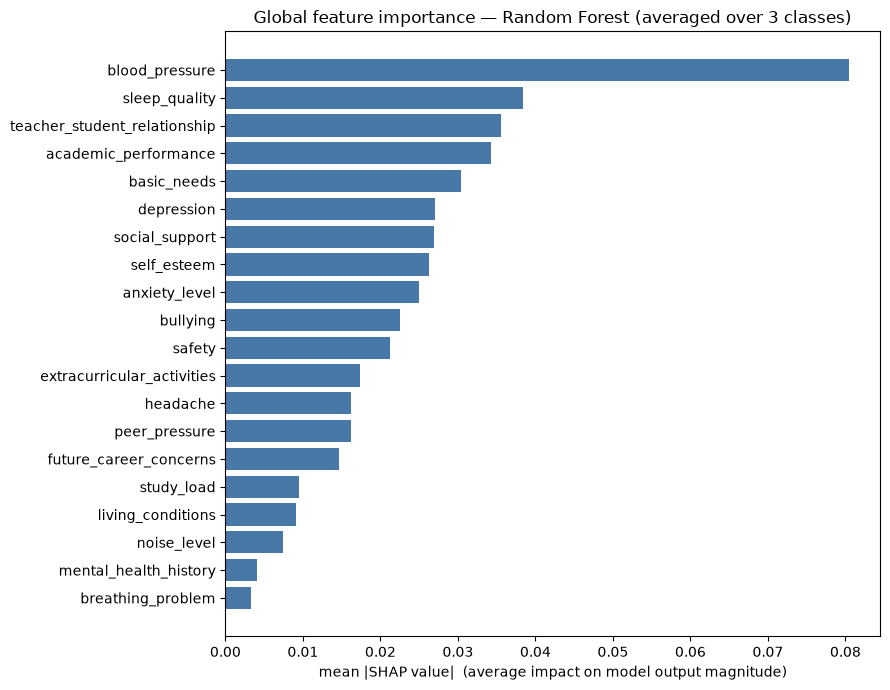

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
ordered = importance.sort_values("mean_abs_shap")
ax.barh(ordered["feature"], ordered["mean_abs_shap"], color="#4878A8")
ax.set_xlabel("mean |SHAP value|  (average impact on model output magnitude)")
ax.set_title("Global feature importance — Random Forest (averaged over 3 classes)")
plt.tight_layout()
plt.show()

### Beeswarm summary — class 2 (high stress)

The beeswarm shows *direction*, not just magnitude: each dot is one test-set
student, positioned by that feature's SHAP contribution, coloured by the
feature's own value. Class 2 (high stress) is shown because it is the class
whose drivers matter most for an early-warning system.

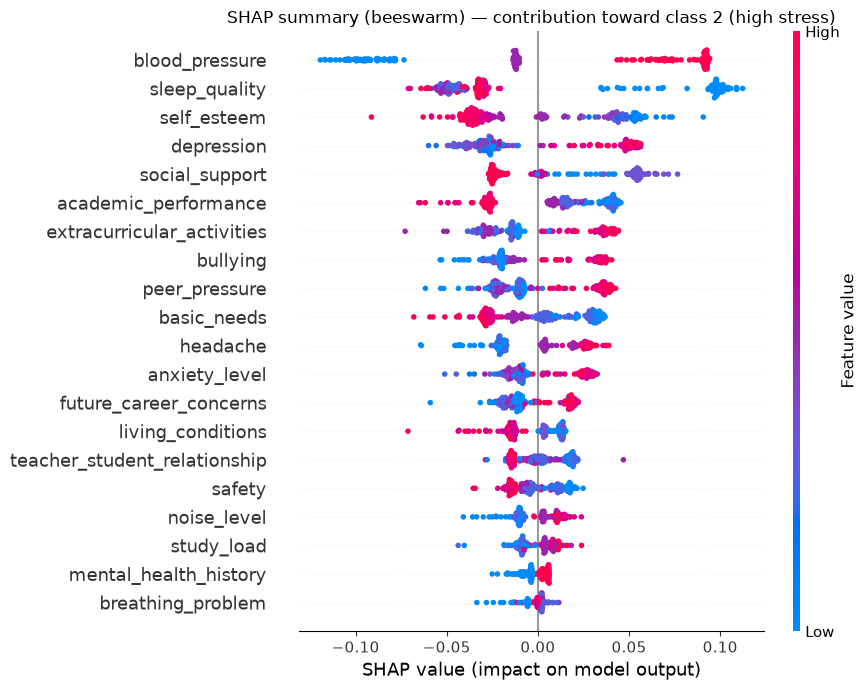

In [7]:
HIGH_STRESS_IDX = CLASS_LABELS.index(2)

shap.summary_plot(
    shap_values[:, :, HIGH_STRESS_IDX],
    X_test,
    feature_names=FEATURE_ORDER,
    show=False,
    plot_size=(9, 7),
)
plt.title("SHAP summary (beeswarm) — contribution toward class 2 (high stress)")
plt.tight_layout()
plt.show()

## Domain sanity check

Per `.claude/skills/explainable-ai/SKILL.md`, SHAP output must be checked
against domain expectations rather than accepted at face value.

Method: for each feature, correlate its **value** against its **SHAP
contribution toward class 2 (high stress)** across the test set. A positive
correlation means higher values of that feature push the model toward
predicting high stress; negative means they push away from it.

Expected directions are stated **before** looking at the results, so this is
a genuine check rather than a post-hoc rationalisation. `ambiguous` marks
features where domain theory does not commit to a direction, so they cannot
be scored as pass/fail.

In [8]:
# Stated in advance, from domain reasoning — not from the model's output.
EXPECTED_DIRECTION = {
    "anxiety_level": "increases",
    "mental_health_history": "increases",
    "depression": "increases",
    "headache": "increases",
    "blood_pressure": "increases",
    "breathing_problem": "increases",
    "noise_level": "increases",
    "study_load": "increases",
    "future_career_concerns": "increases",
    "peer_pressure": "increases",
    "bullying": "increases",
    "self_esteem": "decreases",
    "sleep_quality": "decreases",
    "living_conditions": "decreases",
    "safety": "decreases",
    "basic_needs": "decreases",
    "academic_performance": "decreases",
    "teacher_student_relationship": "decreases",
    "social_support": "decreases",
    # Plausible either way: more activities can mean overcommitment (stress up)
    # or healthy engagement/coping (stress down). No directional claim made.
    "extracurricular_activities": "ambiguous",
}

rows = []
for i, feat in enumerate(FEATURE_ORDER):
    contrib = shap_values[:, i, HIGH_STRESS_IDX]
    corr = np.corrcoef(X_test[feat].values, contrib)[0, 1]
    observed = "increases" if corr > 0 else "decreases"
    expected = EXPECTED_DIRECTION[feat]
    if expected == "ambiguous":
        verdict = "n/a (no prior)"
    elif expected == observed:
        verdict = "OK"
    else:
        verdict = "*** UNEXPECTED ***"
    rows.append(
        {
            "feature": feat,
            "mean_abs_shap": mean_abs_overall[i],
            "corr(value, SHAP->high stress)": corr,
            "expected": expected,
            "observed": observed,
            "verdict": verdict,
        }
    )

sanity = (
    pd.DataFrame(rows)
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)
sanity.index = sanity.index + 1
print("Top 8 features by importance:\n")
print(sanity.head(8).round(4).to_string())
print("\n\nAll 20 features:\n")
print(sanity.round(4).to_string())
print("\n\nUnexpected directions:", (sanity["verdict"] == "*** UNEXPECTED ***").sum())

Top 8 features by importance:

                        feature  mean_abs_shap  corr(value, SHAP->high stress)   expected   observed verdict
1                blood_pressure         0.0804                          0.9884  increases  increases      OK
2                 sleep_quality         0.0385                         -0.7083  decreases  decreases      OK
3  teacher_student_relationship         0.0355                         -0.6137  decreases  decreases      OK
4          academic_performance         0.0343                         -0.9067  decreases  decreases      OK
5                   basic_needs         0.0305                         -0.9010  decreases  decreases      OK
6                    depression         0.0271                          0.8235  increases  increases      OK
7                social_support         0.0270                         -0.8648  decreases  decreases      OK
8                   self_esteem         0.0263                         -0.9286  decreases  decrea

### FLAGGED: `blood_pressure` dominance is a dataset artifact, not a finding

The sanity check above passes on *direction* for all 19 features with a prior
— but the *magnitude* ranking contains a serious anomaly that must not be
reported as a substantive result.

`blood_pressure` has more than double the mean |SHAP| of any other feature
(0.0804 vs 0.0385 for the next), yet in `01_EDA.ipynb` it had the **weakest**
linear correlation with the target of any feature (r = +0.394, where others
reached |r| = 0.75). Those two facts are irreconcilable unless the
relationship is non-linear — which is exactly what the cells below confirm.

Pearson correlation, and therefore the entire EDA correlation heatmap, was
structurally blind to this: the mapping is non-monotonic, so a linear
coefficient cannot see it.

In [9]:
# Why is blood_pressure so dominant? Inspect its actual relationship to the target.
ct_counts = pd.crosstab(df["blood_pressure"], df[TARGET])
ct_norm = pd.crosstab(df["blood_pressure"], df[TARGET], normalize="index")

print("Counts: blood_pressure x stress_level")
print(ct_counts)
print("\nRow-normalised, P(stress_level | blood_pressure):")
print(ct_norm.round(3))

deterministic = ct_norm.max(axis=1) == 1.0
print(f"\nblood_pressure values that map to a single class with 100% purity: "
      f"{list(ct_norm.index[deterministic])}")
share = df["blood_pressure"].isin(ct_norm.index[deterministic]).mean()
print(f"Share of the full dataset those values cover: {share:.1%}")

Counts: blood_pressure x stress_level
stress_level      0    1    2
blood_pressure               
1                 0  300    0
2               300    0    0
3                73   58  369

Row-normalised, P(stress_level | blood_pressure):
stress_level        0      1      2
blood_pressure                     
1               0.000  1.000  0.000
2               1.000  0.000  0.000
3               0.146  0.116  0.738

blood_pressure values that map to a single class with 100% purity: [1, 2]
Share of the full dataset those values cover: 54.5%


The mapping is **near-deterministic and non-monotonic**:

- `blood_pressure = 1` → `stress_level = 1` (moderate) in **100%** of rows
- `blood_pressure = 2` → `stress_level = 0` (low) in **100%** of rows
- `blood_pressure = 3` → `stress_level = 2` (high) in 73.8% of rows

For **54.5% of the dataset, this single feature determines the label
perfectly.** Because the value order (1→class 1, 2→class 0, 3→class 2) does
not follow the class order, linear correlation reads it as weak.

This is not plausible as a physiological measurement. Real blood pressure
does not partition a stress label into exact, zero-overlap blocks of 300
rows. The far more likely explanation is that this column was **generated
from the label** when the dataset was constructed — i.e. target leakage baked
into the published data.

The test below quantifies what that means for every model result in this
project.

In [10]:
# How much of the model's performance is just this one feature?
# Rule is derived from TRAINING data only, then applied to the same held-out test set.
rule = X_train.assign(_y=y_train).groupby("blood_pressure")["_y"].agg(lambda s: s.mode()[0])
trivial_pred = X_test["blood_pressure"].map(rule)

trivial_acc = accuracy_score(y_test, trivial_pred)
trivial_f1 = f1_score(y_test, trivial_pred, average="macro")

print("Lookup rule learned from training data:")
print(rule.to_string(), "\n")
print(f"{'':34s} {'accuracy':>10s} {'f1_macro':>10s}")
print(f"{'ONE-feature blood_pressure lookup':34s} {trivial_acc:10.4f} {trivial_f1:10.4f}")
print(f"{'Tuned 20-feature Random Forest':34s} {acc:10.4f} {f1:10.4f}")
print(f"{'Difference':34s} {acc - trivial_acc:+10.4f} {f1 - trivial_f1:+10.4f}")

Lookup rule learned from training data:
blood_pressure
1    1
2    0
3    2 

                                     accuracy   f1_macro
ONE-feature blood_pressure lookup      0.8864     0.8890
Tuned 20-feature Random Forest         0.8864     0.8861
Difference                            +0.0000    -0.0029


**Result: a three-line lookup table on one feature equals the tuned
20-feature Random Forest on accuracy (0.8864 vs 0.8864) and beats it on
macro F1 (0.8890 vs 0.8861).**

Consequences that must be carried into the results and limitations chapters:

1. **The comparative model evaluation measured very little.** All five models
   scored within 0.873–0.886 because all five found the same lookup rule.
   That tight band was not evidence that the problem is easy or that the
   models are good — it is the signature of a single dominant shortcut.
2. **The reported ~88% figures are close to an artifact ceiling**, not a
   measure of genuine stress-prediction capability. They should not be
   compared to the literature's 63–99% range as though measuring the same
   thing.
3. **The 19 correct SHAP directions above are still real**, but they describe
   the model's much smaller residual reasoning, applied mostly to the 45.5%
   of rows where `blood_pressure = 3` does not settle the answer.
4. **This does not invalidate the framework** — the pipeline, explainability
   method, and evaluation protocol are all sound and were what surfaced this.
   It invalidates treating *this dataset's* numbers as evidence of real-world
   performance, which is precisely the risk `methodology.md` committed to
   handling via external validation.

**No feature is dropped here.** Re-running the comparison without
`blood_pressure` would give a more honest measure of the other 19 features'
predictive value, and is worth doing — but that is a modelling decision to
take deliberately, not a change to make silently inside an explainability
notebook.

## Local explanations — 4 individual test-set students

In [11]:
# Select: one confidently-correct example per class, plus one misclassification.
confidence = y_proba.max(axis=1)
correct = (y_pred == y_test.values)

selected = {}
for c in CLASS_LABELS:
    mask = correct & (y_test.values == c)
    if mask.any():
        # most confident correct prediction for this class
        idx = np.where(mask)[0][np.argmax(confidence[mask])]
        selected[f"correct_class_{c}_{CLASS_MEANING[str(c)]}"] = idx

wrong = np.where(~correct)[0]
if len(wrong):
    # most confident *wrong* prediction - the most instructive failure case
    idx = wrong[np.argmax(confidence[wrong])]
    selected[f"MISCLASSIFIED_true{y_test.values[idx]}_pred{y_pred[idx]}"] = idx

for name, idx in selected.items():
    print(f"{name:38s} row {idx:3d}  true={y_test.values[idx]}  "
          f"pred={y_pred[idx]}  confidence={confidence[idx]:.3f}")

correct_class_0_low                    row   0  true=0  pred=0  confidence=1.000
correct_class_1_moderate               row   8  true=1  pred=1  confidence=1.000
correct_class_2_high                   row   2  true=2  pred=2  confidence=1.000
MISCLASSIFIED_true1_pred0              row  85  true=1  pred=0  confidence=0.547


correct_class_0_low   (test row 0)
true=0 (low)  pred=0 (low)  confidence=1.000
Explaining contributions toward predicted class 0; base value 0.3413


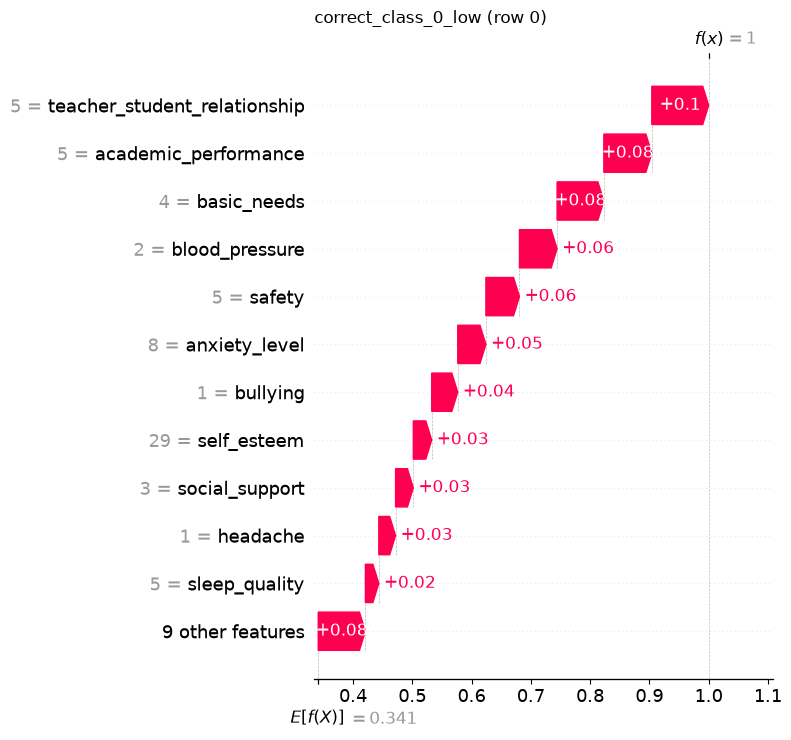

correct_class_1_moderate   (test row 8)
true=1 (moderate)  pred=1 (moderate)  confidence=1.000
Explaining contributions toward predicted class 1; base value 0.3244


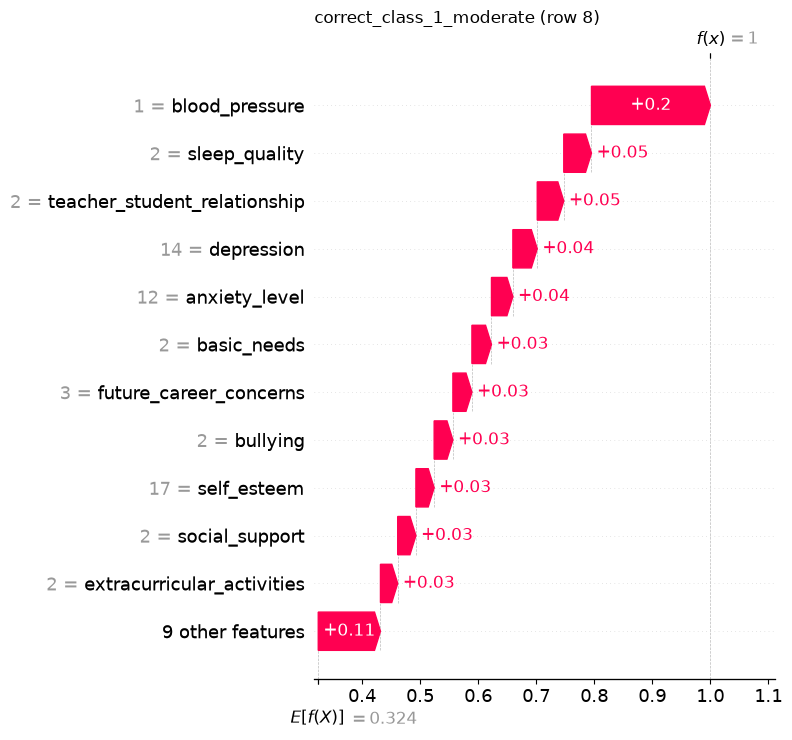

correct_class_2_high   (test row 2)
true=2 (high)  pred=2 (high)  confidence=1.000
Explaining contributions toward predicted class 2; base value 0.3343


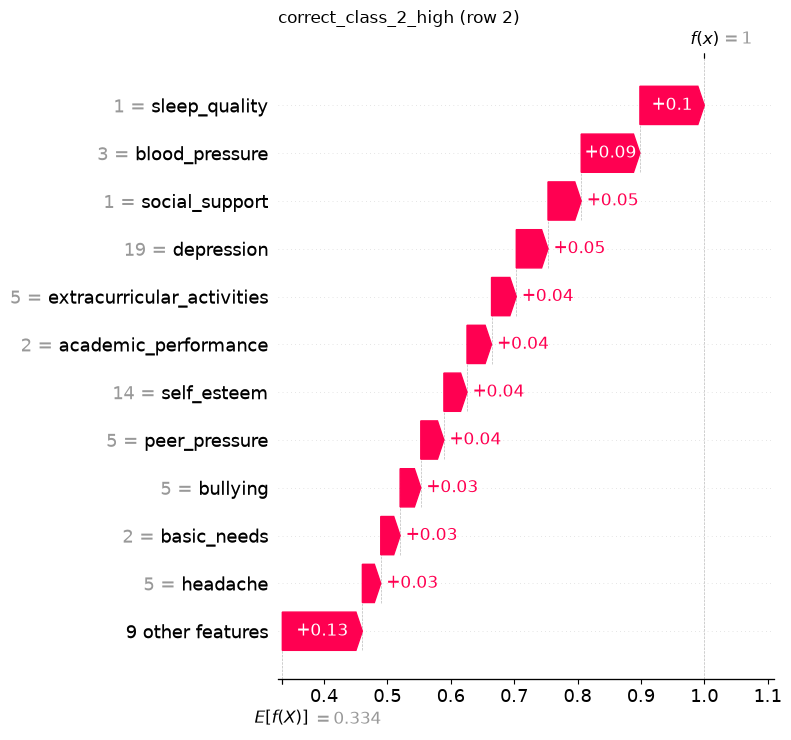

MISCLASSIFIED_true1_pred0   (test row 85)
true=1 (moderate)  pred=0 (low)  confidence=0.547
Explaining contributions toward predicted class 0; base value 0.3413


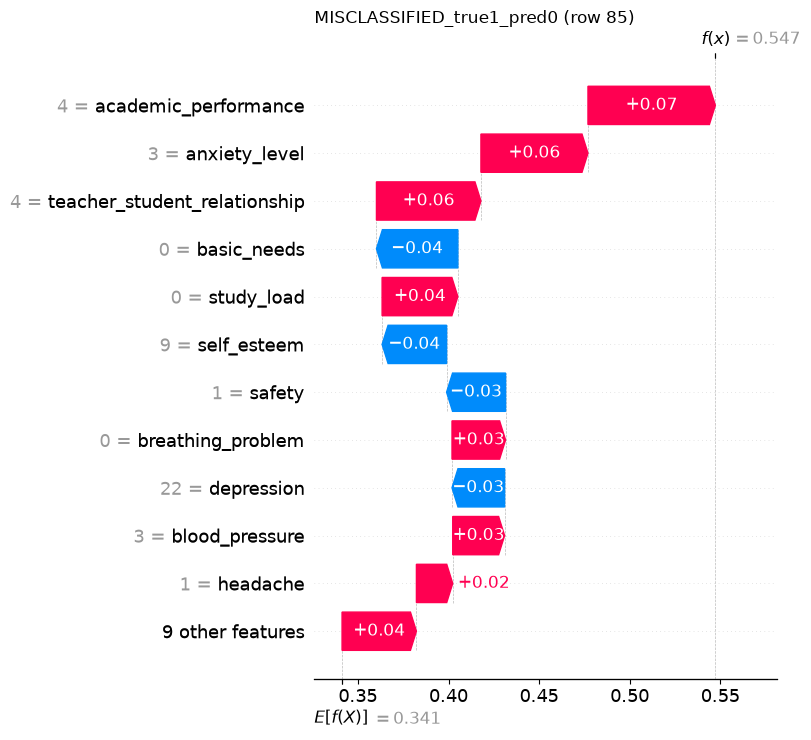

In [12]:
for name, idx in selected.items():
    predicted_class = int(y_pred[idx])
    class_idx = CLASS_LABELS.index(predicted_class)

    explanation = shap.Explanation(
        values=shap_values[idx, :, class_idx],
        base_values=base_values[class_idx],
        data=X_test.iloc[idx].values,
        feature_names=FEATURE_ORDER,
    )

    print("=" * 78)
    print(f"{name}   (test row {idx})")
    print(f"true={y_test.values[idx]} ({CLASS_MEANING[str(y_test.values[idx])]})  "
          f"pred={predicted_class} ({CLASS_MEANING[str(predicted_class)]})  "
          f"confidence={confidence[idx]:.3f}")
    print(f"Explaining contributions toward predicted class {predicted_class}; "
          f"base value {base_values[class_idx]:.4f}")
    print("=" * 78)

    shap.plots.waterfall(explanation, max_display=12, show=False)
    plt.title(f"{name} (row {idx})", loc="left")
    plt.tight_layout()
    plt.show()

### Feature values alongside SHAP contributions

The waterfall plots above truncate to the top contributors. This table shows
every feature's actual value next to its SHAP contribution for each selected
student, so nothing is hidden by the plot's display limit.

In [13]:
local_tables = {}
for name, idx in selected.items():
    class_idx = CLASS_LABELS.index(int(y_pred[idx]))
    tbl = pd.DataFrame(
        {
            "feature_value": X_test.iloc[idx].values,
            "shap_contribution": shap_values[idx, :, class_idx],
        },
        index=FEATURE_ORDER,
    ).sort_values("shap_contribution", key=abs, ascending=False)
    local_tables[name] = tbl

    print("=" * 70)
    print(name, f"(row {idx})")
    print("=" * 70)
    print(tbl.round(4).to_string())
    print()

correct_class_0_low (row 0)
                              feature_value  shap_contribution
teacher_student_relationship              5             0.0959
academic_performance                      5             0.0810
basic_needs                               4             0.0789
blood_pressure                            2             0.0635
safety                                    5             0.0566
anxiety_level                             8             0.0475
bullying                                  1             0.0439
self_esteem                              29             0.0310
social_support                            3             0.0299
headache                                  1             0.0283
sleep_quality                             5             0.0226
depression                                1             0.0221
future_career_concerns                    1             0.0216
living_conditions                         3             0.0101
noise_level                

## Export `shap_config.json`

What `backend/app/explainability` needs to reproduce these explanations at
inference time without recomputing anything from the training data: the
explainer type, the per-class base values, and the exact feature order the
SHAP array is indexed by.

Note this stores configuration and reference values, **not** per-student SHAP
values — those are computed per prediction at request time.

In [14]:
from datetime import datetime, timezone

from src.experiments.logger import hash_file

shap_config = {
    "model_version": feature_schema["model_version"],
    "created_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "explainer": {
        "type": "TreeExplainer",
        "library": "shap",
        "library_version": shap.__version__,
        "exact": True,
        "rationale": "Random Forest is a tree ensemble, so Shapley values are exact rather than approximated.",
    },
    "model_artifact": {
        "filename": MODEL_PATH.name,
        "sha256": hash_file(MODEL_PATH),
    },
    "target": {
        "name": TARGET,
        "classes": CLASS_LABELS,
        "class_meaning": CLASS_MEANING,
    },
    # Order matters: shap_values is indexed [sample, feature_position, class_position].
    "feature_order": FEATURE_ORDER,
    "base_values_per_class": {str(c): float(base_values[i]) for i, c in enumerate(CLASS_LABELS)},
    "shap_values_shape": "(n_samples, n_features, n_classes)",
    "global_importance_ranking": [
        {"rank": int(r), "feature": row["feature"], "mean_abs_shap": float(row["mean_abs_shap"])}
        for r, row in importance.iterrows()
    ],
    "computed_on": {
        "split": "held-out test set reproduced from 03_ModelTraining.ipynb",
        "n_samples": int(X_test.shape[0]),
        "dataset_sha256": hash_file(DATA_PATH),
    },
    "usage_note": (
        "Consumed by backend/app/explainability. Raw SHAP values must never reach an end "
        "user - they are translated by the Human-Centered Explanation Generator first."
    ),
}

config_path = ARTIFACTS_DIR / "shap_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(shap_config, f, indent=2)

print(f"Saved: {config_path}")
print(json.dumps({k: v for k, v in shap_config.items() if k != "global_importance_ranking"}, indent=2))

Saved: ../artifacts/shap_config.json
{
  "model_version": "v1",
  "created_utc": "2026-08-15T07:49:20Z",
  "explainer": {
    "type": "TreeExplainer",
    "library": "shap",
    "library_version": "0.52.0",
    "exact": true,
    "rationale": "Random Forest is a tree ensemble, so Shapley values are exact rather than approximated."
  },
  "model_artifact": {
    "filename": "stress_model_v1.pkl",
    "sha256": "a5f9fe7f57d39318eef33ad293308965936c011964fc43327a35ca70ba274e6f"
  },
  "target": {
    "name": "stress_level",
    "classes": [
      0,
      1,
      2
    ],
    "class_meaning": {
      "0": "low",
      "1": "moderate",
      "2": "high"
    }
  },
  "feature_order": [
    "anxiety_level",
    "self_esteem",
    "mental_health_history",
    "depression",
    "headache",
    "blood_pressure",
    "sleep_quality",
    "breathing_problem",
    "noise_level",
    "living_conditions",
    "safety",
    "basic_needs",
    "academic_performance",
    "study_load",
    "teacher_st